In [1]:
!pip install torch torchvision matplotlib -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

In [4]:
class ImprovedSelfPruningNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc1 = PrunableLinear(128*4*4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [5]:
def sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if hasattr(module, 'gate_scores'):
            gates = torch.sigmoid(module.gate_scores)
            loss += gates.sum()
    return loss

In [6]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64)

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


In [7]:
def train_model(lambda_val, epochs=30):

    model = ImprovedSelfPruningNN().to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            ce_loss = criterion(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = ce_loss + lambda_val * sp_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model

In [8]:
def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


def calculate_sparsity(model):
    total = 0
    pruned = 0

    for module in model.modules():
        if hasattr(module, 'gate_scores'):
            gates = torch.sigmoid(module.gate_scores)

            total += gates.numel()
            pruned += (gates < 1e-2).sum().item()

    return 100 * pruned / total

In [9]:
lambdas = [1e-6, 5e-6, 1e-5]
results = []
models = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam)

    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    results.append((lam, acc, sparsity))
    models.append(model)

    print(f"Accuracy: {acc:.2f}%, Sparsity: {sparsity:.2f}%")


Training with lambda = 1e-06
Epoch 1, Loss: 1548.8843
Epoch 2, Loss: 1317.1898
Epoch 3, Loss: 1226.4545
Epoch 4, Loss: 1166.4410
Epoch 5, Loss: 1125.6201
Epoch 6, Loss: 1074.7575
Epoch 7, Loss: 1050.2233
Epoch 8, Loss: 1036.7521
Epoch 9, Loss: 1021.0184
Epoch 10, Loss: 1007.8164
Epoch 11, Loss: 985.6240
Epoch 12, Loss: 975.8523
Epoch 13, Loss: 973.3153
Epoch 14, Loss: 964.9153
Epoch 15, Loss: 960.7491
Epoch 16, Loss: 949.0900
Epoch 17, Loss: 945.0688
Epoch 18, Loss: 942.5049
Epoch 19, Loss: 937.3932
Epoch 20, Loss: 934.8996
Epoch 21, Loss: 931.3645
Epoch 22, Loss: 928.4535
Epoch 23, Loss: 926.2878
Epoch 24, Loss: 926.7479
Epoch 25, Loss: 924.9696
Epoch 26, Loss: 920.7517
Epoch 27, Loss: 920.7394
Epoch 28, Loss: 920.0978
Epoch 29, Loss: 919.0156
Epoch 30, Loss: 918.9171
Accuracy: 79.06%, Sparsity: 0.64%

Training with lambda = 5e-06
Epoch 1, Loss: 2309.6770
Epoch 2, Loss: 2000.5269
Epoch 3, Loss: 1840.1797
Epoch 4, Loss: 1717.4230
Epoch 5, Loss: 1622.7053
Epoch 6, Loss: 1535.5902
Epoch

In [10]:
print("\nFinal Results:")
print("Lambda\t\tAccuracy\tSparsity")

for r in results:
    print(f"{r[0]}\t{r[1]:.2f}%\t\t{r[2]:.2f}%")


Final Results:
Lambda		Accuracy	Sparsity
1e-06	79.06%		0.64%
5e-06	78.87%		2.38%
1e-05	78.59%		2.88%


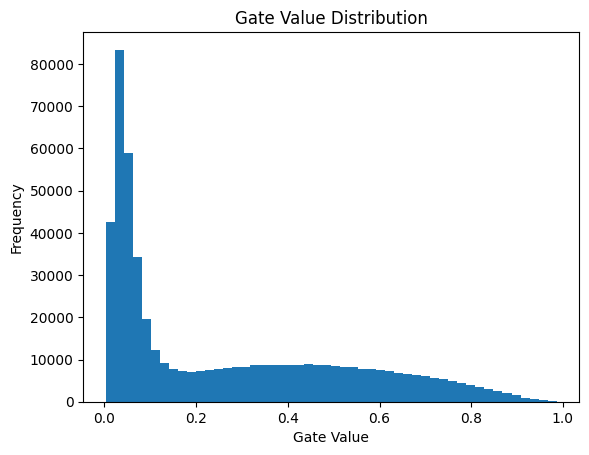

In [11]:
def plot_gates(model):
    all_gates = []

    for module in model.modules():
        if hasattr(module, 'gate_scores'):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()

plot_gates(models[0])